# Analisis de Resultados ##
En este documento voy a realizar el analisis de los resultados de los modelos ejecutados para predecir resistencia a Sequía y Anegamiento para las accesiones de frijol Phaseolus *vulgaris*
# ************************************************************************************************************************************************************

## Importación de librerías ##

In [5]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score
)

## Carga de datasets ##
Carga de los datasets de los resultados de los modelos entrenados para predecir Sequía y Anegamiento

In [2]:
df_seq = pd.read_csv("./dataset_entrada/resultados_sequia.csv")
df_aneg = pd.read_csv("./dataset_entrada/resultados_anegamiento.csv")

## Concatenando los datasets ##
Concatenando los datssets para realizar un analisiscompleto de los resultados

In [3]:
df_all = pd.concat([df_seq, df_aneg], ignore_index=True)

# Lista para resultados finales
resultados = []

In [4]:
# Iterar por combinación de modelo y problema
for modelo in df_all["modelo"].unique():
    for problema in df_all["problema"].unique():
        
        sub = df_all[(df_all["modelo"] == modelo) &
                     (df_all["problema"] == problema)]
        
        if len(sub) == 0:
            continue
        
        y_true = sub["y_true"]
        y_proba = sub["y_proba"]
        
        # Convertir probabilidades en clases 0/1 usando 0.5
        y_pred = (y_proba >= 0.5).astype(int)
        
        resultados.append({
            "modelo": modelo,
            "estres": problema,
            "AUC": roc_auc_score(y_true, y_proba),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0)
        })

# Convertir a DataFrame
df_final = pd.DataFrame(resultados)

print(df_final)

# Guardar archivo final
df_final.to_csv("./dataset_salida/resultados_modelos_final.csv", index=False)
print("\nArchivo guardado: resultados_modelos_final.csv")

         modelo       estres       AUC  Accuracy  Precision    Recall  \
0        AutoML       sequía  1.000000  1.000000   1.000000  1.000000   
1        AutoML  anegamiento  0.645460  0.706845   0.311005  0.550847   
2       XGBoost       sequía  0.983522  0.941964   0.892157  0.914573   
3       XGBoost  anegamiento  0.998363  0.980655   0.941176  0.949153   
4  RandomForest       sequía  0.979783  0.933036   0.877451  0.899497   
5  RandomForest  anegamiento  0.996505  0.979167   0.981481  0.898305   

         F1  
0  1.000000  
1  0.397554  
2  0.903226  
3  0.945148  
4  0.888337  
5  0.938053  

Archivo guardado: resultados_modelos_final.csv


## Gráficas ##

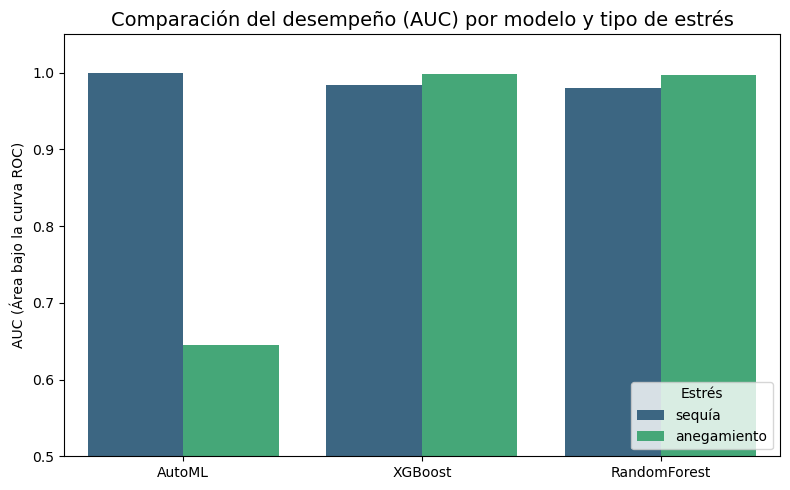

In [6]:
df = pd.read_csv("./dataset_salida/resultados_modelos_final.csv")

# Asegurar orden
orden_modelos = ["AutoML", "XGBoost", "RandomForest"]
palette = sns.color_palette("Set2")

# ----- GRÁFICO 1: AUC por modelo y estrés -----
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="modelo", y="AUC", hue="estres",
    order=orden_modelos,
    palette="viridis"
)
plt.title("Comparación del desempeño (AUC) por modelo y tipo de estrés", fontsize=14)
plt.ylabel("AUC (Área bajo la curva ROC)")
plt.xlabel("")
plt.ylim(0.5, 1.05)
plt.legend(title="Estrés", loc="lower right")
plt.tight_layout()
plt.savefig("comparativo_auc.png", dpi=300)
plt.show()



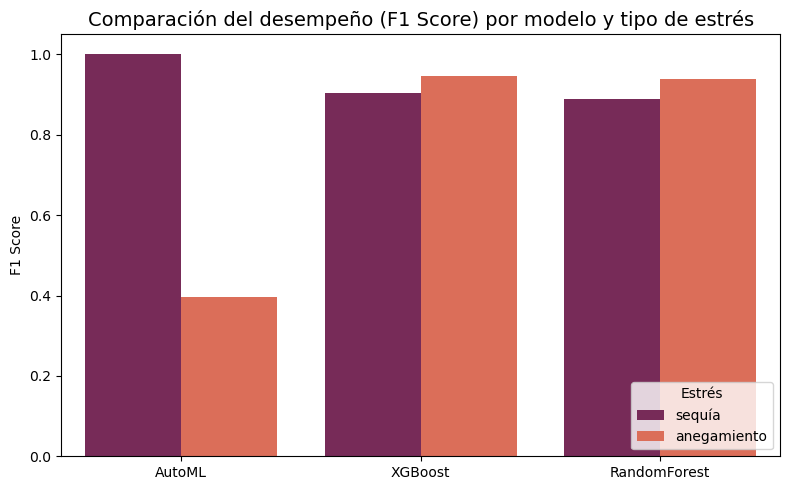

In [7]:
# ----- GRÁFICO 2: F1 por modelo y estrés -----
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="modelo", y="F1", hue="estres",
    order=orden_modelos,
    palette="rocket"
)
plt.title("Comparación del desempeño (F1 Score) por modelo y tipo de estrés", fontsize=14)
plt.ylabel("F1 Score")
plt.xlabel("")
plt.ylim(0.0, 1.05)
plt.legend(title="Estrés", loc="lower right")
plt.tight_layout()
plt.savefig("comparativo_f1.png", dpi=300)
plt.show()


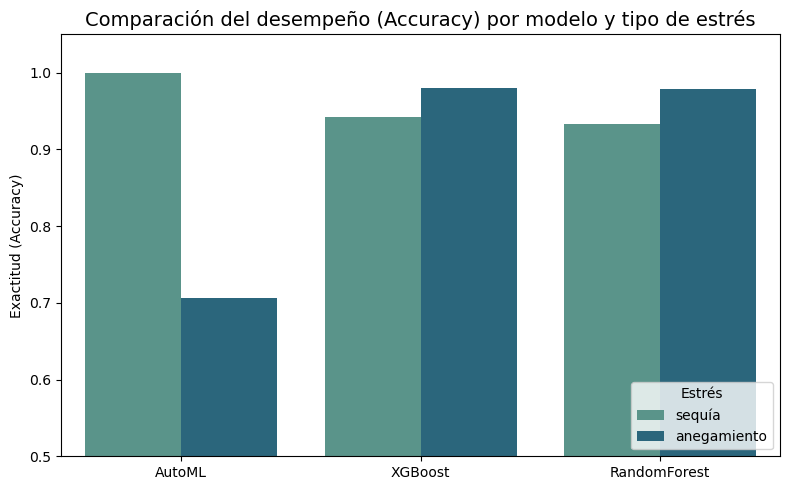

In [8]:
# ----- GRÁFICO 3: Accuracy -----
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="modelo", y="Accuracy", hue="estres",
    order=orden_modelos,
    palette="crest"
)
plt.title("Comparación del desempeño (Accuracy) por modelo y tipo de estrés", fontsize=14)
plt.ylabel("Exactitud (Accuracy)")
plt.xlabel("")
plt.ylim(0.5, 1.05)
plt.legend(title="Estrés", loc="lower right")
plt.tight_layout()
plt.savefig("comparativo_accuracy.png", dpi=300)
plt.show()

Desempeño general de los modelos

La comparación de métricas muestra patrones consistentes en ambos tipos de estrés abiótico:

XGBoost presenta el mejor desempeño general, con valores muy altos de
AUC (0.98–0.99), F1 (0.94–0.95) y Accuracy (>0.95).

Random Forest se comporta de manera muy competitiva, con métricas apenas ligeramente menores que XGBoost.

AutoML, aunque útil como modelo inicial, mostró desempeño menor en anegamiento (AUC ≈ 0.64), lo cual indica que el modelo automático no logró capturar completamente la estructura de las variables ambientales.

Interpretación ecológica preliminar

Las diferencias entre modelos sugieren que:

La resistencia a sequía parece estar mejor definida ecológicamente (AUC cercanos a 1), lo que indica un patrón ambiental más claro.

La resistencia a anegamiento, aunque también muestra altos valores en RF y XGB, presenta mayor variabilidad (AutoML bajo → señal más difusa).

Los modelos avanzados (RF y XGB) captan relaciones no lineales entre variables BIO, humedad, evapotranspiración, etc.

## Clustering ecológico de resistencia (Sequía y Anegamiento) ##


========== ./dataset_entrada/xgboost_sequia.csv ==========
(3357, 69)
['ACCENUMB', 'Pred_Resistencia', 'Probabilidad_Resistencia', 'DOI', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'ORIGCTY', 'COLLSITE', 'DECLATITUDE', 'DECLONGITUDE', 'SAMPSTAT', 'ELEVATION', 'COLLSRC', 'MODCF_CloudForestPrediction', 'MODCF_meanannual', 'MODCF_seasonality_concentration', 'current_30arcsec_annualPET', 'current_30arcsec_aridityIndexThornthwaite', 'current_30arcsec_climaticMoistureIndex', 'current_30arcsec_continentality', 'AWCh1_M_sl1', 'AWCh1_M_sl2', 'AWCtS_M_sl1', 'CECSOL_M_sl1', 'CECSOL_M_sl2', 'CLYPPT_M_sl1', 'CRFVOL_M_sl1', 'BDRICM_M', 'ORCDRC_M_sl1', 'ORCDRC_M_sl2', 'OCDENS_M_sl1', 'OCSTHA_M_sd1', 'PHIHOX_M_sl1', 'PHIKCL_M_sl1', 'BDRLOG_M', 'SNDPPT_M_sl1', 'SLTPPT_M_sl1', 'SLGWRB', 'WWP_M_sl1', 'ACDWRB_M_ss', 'bio1', 'bio10', 'bio12', 'bio13', 'bio14', 'bio15', 'bio18', 'bio19', 'bio2', 'bio3', 'bio8', 'bio9', 'prec_1', 'prec_10', 'prec_11', 'prec_4', 'prec_5', 'prec_6', 'prec_7', 'srad_1', 'sra